In [1]:
import pandas as pd

###`Q-1:` You are given a Multi index DataFrame. You task is to swap level-0 index with level-0 column.
* Change Branch -> ('cse', 'ece') as columns at level-0 and ('delhi'	'mumbai') as level-0 Index
* And Sort on row index level-0

In [2]:
# Given Code Snippets
index_val = [('cse',2019),('cse',2020),('cse',2021),('cse',2022),('ece',2019),('ece',2020),('ece',2021),('ece',2022)]
multiindex = pd.MultiIndex.from_tuples(index_val)
df = pd.DataFrame(
    [
        [1,2,0,0],
        [3,4,0,0],
        [5,6,0,0],
        [7,8,0,0],
        [9,10,0,0],
        [11,12,0,0],
        [13,14,0,0],
        [15,16,0,0],
    ],
    index = multiindex,
    columns = pd.MultiIndex.from_product([['delhi','mumbai'],['avg_package','students']])
)

df

delhi               mumbai         
         avg_package students avg_package students
cse 2019           1        2           0        0
    2020           3        4           0        0
    2021           5        6           0        0
    2022           7        8           0        0
ece 2019           9       10           0        0
    2020          11       12           0        0
    2021          13       14           0        0
    2022          15       16           0        0

In [3]:
# code here

In [4]:
# swap index level-0 with column level-0
out = (
    df
    .stack(0)          # move column level-0 ('delhi','mumbai') into index
    .unstack(0)        # move index level-0 ('cse','ece') into columns
    .sort_index(level=0)
)

out


/tmp/ipython-input-1548504597.py:4: FutureWarning: The previous implementation of stack is deprecated and will be removed in a future version of pandas. See the What's New notes for pandas 2.1.0 for details. Specify future_stack=True to adopt the new implementation and silence this warning.
  .stack(0)          # move column level-0 ('delhi','mumbai') into index


avg_package     students    
                    cse ece      cse ece
2019 delhi            1   9        2  10
     mumbai           0   0        0   0
2020 delhi            3  11        4  12
     mumbai           0   0        0   0
2021 delhi            5  13        6  14
     mumbai           0   0        0   0
2022 delhi            7  15        8  16
     mumbai           0   0        0   0

###`Q-2:` Covid Cases Data Set Problem
 Make a DataFrame Using both Covid Dataset. With Country name as Level-0 and Provinance/State as Level-1 Index and date, No of cases and No of Deaths as Columns.

In [5]:
confirm = pd.read_csv('https://docs.google.com/spreadsheets/d/e/2PACX-1vTmqT3kxd0i0RUFiEnwA1Hboiunv28MeNTatZsIEqlPPB7mHrl0ttJL7utZ23_1s5FW8ZjODmB8jHIi/pub?gid=2142019845&single=true&output=csv')

deaths = pd.read_csv("https://docs.google.com/spreadsheets/d/e/2PACX-1vQn4nLCKIVZMw4e89YeRqgKaSAAwRFaZ6ILMW_FUejZ2tkv3Np1f9gD4QOl3ASHeLzWjOjfmLDKcCOF/pub?gid=212966958&single=true&output=csv")

In [7]:
id_cols = ['Country/Region', 'Province/State']

confirm_long = confirm.melt(
    id_vars=id_cols,
    var_name='Date',
    value_name='No_of_Cases'
)

deaths_long = deaths.melt(
    id_vars=id_cols,
    var_name='Date',
    value_name='No_of_Deaths'
)


In [8]:
df = pd.merge(
    confirm_long,
    deaths_long,
    on=['Country/Region', 'Province/State', 'Date'],
    how='inner'
)


In [9]:
df = df.set_index(['Country/Region', 'Province/State'])


In [10]:
df

,,Date,No_of_Cases,No_of_Deaths
Country/Region,Province/State,,,
Afghanistan,NaN,Lat,33.93911,33.93911
Albania,NaN,Lat,41.15330,41.15330
Algeria,NaN,Lat,28.03390,28.03390
Andorra,NaN,Lat,42.50630,42.50630
Angola,NaN,Lat,-11.20270,-11.20270
...,...,...,...,...
West Bank and Gaza,NaN,1/2/23,703228.00000,5708.00000
Winter Olympics 2022,NaN,1/2/23,535.00000,0.00000
Yemen,NaN,1/2/23,11945.00000,2159.00000


###`Q-3:` Show Country with Heighest death percent out of confirmed Cases.

In [ ]:
# code here

In [11]:
latest_date = df['Date'].max()


In [13]:
latest_df = df[df['Date'] == latest_date]


In [14]:
country_totals = (
    latest_df
    .groupby(level=0)[['No_of_Cases', 'No_of_Deaths']]
    .sum()
)


In [15]:
country_totals['Death_Percent'] = (
    country_totals['No_of_Deaths'] / country_totals['No_of_Cases']
) * 100


In [16]:
country_totals.sort_values('Death_Percent', ascending=False).head(1)


,No_of_Cases,No_of_Deaths,Death_Percent
Country/Region,,,
Afghanistan,67.709953,67.709953,100.0


### `Q-4` : Make a dataframe for India from Covid Data with one extra column representing no of new cases.

* Just for Assumption "No of new cases" will be equal to difference of "no of cases" with previous day.
* First day new cases will be NaN or equal to no of cases

Say on 12/30/22 No of cases is - 44679608	and a day previous (12/29/22) no of cases is - 44679382.

Then for 12/30/22 -> No of New Cases  = 44679608 - 44679382 =

Note:- Try using shift Function

Try using the shift function

```
s = pd.Series([1,2,3,4,5,6])
s #-> [1,2,3,4,5,6]
s.shift(1) #-> [NaN, 1,2,3,4,5]
s.shift(-1) #-> [2,3,4,5,6, NaN]
```

In [17]:
# code here

### `Q-5:` Read the Dataset using the below given link and create a multi-index dataframe using the columns "Country" and "City/Town".

This dataset is about the most polluted cities in the world. You can get details from [here](https://www.kaggle.com/datasets/rajkumarpandey02/worlds-most-air-polluted-countries-cities).

**Dataset link:** https://tinyurl.com/2fe6vz4u Directly use this link to read.

**Task:**
1. Find out the name of the city of India which is most poluted based on PM10.
2. Find out the name of the city of India which has minumum pollution level based on PM10.
3. Do same operations (like 1 and 2) with the country China.
4. Make a pie chart based on the column "PM10" of the country Poland.
5. Make a bar chart based on the columns "PM2.5" and "PM10" of the countries Israel and Qatar.
6. Convert this MultiIndex DataFrame to Series by retaining the informations.

In [18]:
# code here

In [19]:
url = "https://tinyurl.com/2fe6vz4u"
df = pd.read_csv(url)

In [20]:
# 2️⃣ Create MultiIndex using Country and City/Town
df = df.set_index(['Country', 'City/Town'])

In [21]:
# 3️⃣ Most & least polluted in India based on PM10
india = df.loc['India']
most_pm10_india = india['PM10'].idxmax()
min_pm10_india = india['PM10'].idxmin()

In [22]:
print("Most polluted city in India (PM10):", most_pm10_india)
print("Least polluted city in India (PM10):", min_pm10_india)

Most polluted city in India (PM10): Kanpur
Least polluted city in India (PM10): Aizawl


In [23]:
# 4️⃣ Most & least polluted in China based on PM10
china = df.loc['China']
most_pm10_china = china['PM10'].idxmax()
min_pm10_china = china['PM10'].idxmin()


In [24]:
print("Most polluted city in China (PM10):", most_pm10_china)
print("Least polluted city in China (PM10):", min_pm10_china)


Most polluted city in China (PM10): Jinan
Least polluted city in China (PM10): Anshun


In [26]:
import matplotlib.pyplot as plt

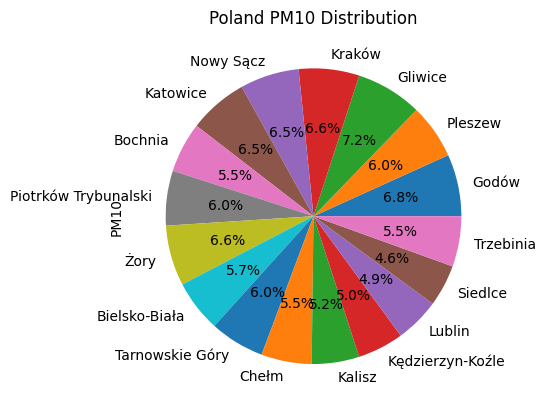

In [27]:
# 5️⃣ Pie chart for Poland's PM10
poland = df.loc['Poland']
poland['PM10'].plot(kind='pie', autopct='%1.1f%%', title='Poland PM10 Distribution')

plt.show()

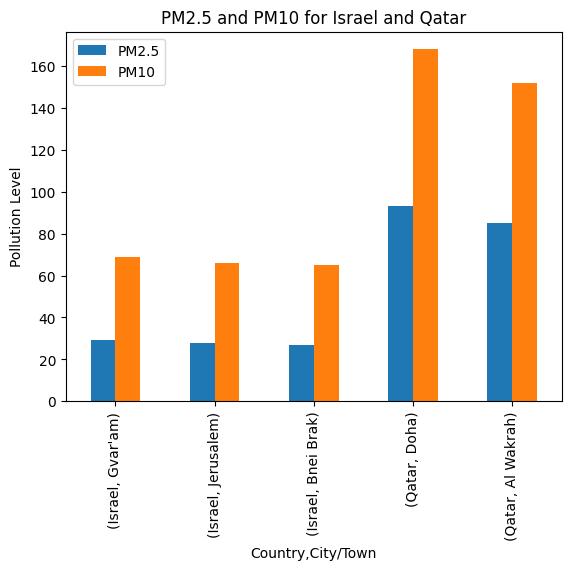

In [28]:
# 6️⃣ Bar chart for Israel and Qatar
israel_qatar = df.loc[['Israel','Qatar'], ['PM2.5', 'PM10']]
israel_qatar.plot(kind='bar')
plt.title('PM2.5 and PM10 for Israel and Qatar')
plt.ylabel('Pollution Level')
plt.show()


In [30]:
# 7️⃣ Convert MultiIndex DataFrame to Series
series = df.stack()
series

Country  City/Town                         
India    Kanpur     Unnamed: 0                    0
                    Position                      1
                    Year                       2016
                    PM2.5                       173
                    Temporal coverage          >75%
                                               ... 
Turkey   Sivas      PM2.5                        27
                    Temporal coverage          >75%
                    PM10                         56
                    Temporal coverage.1        >75%
                    Database version (year)    2018
Length: 3138, dtype: object